<a href="https://colab.research.google.com/github/Pratik1489287/Pratik1489287/blob/main/Cryptocurrency_Market_Analysis_%26_Price_Movement_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cryptocurrency Market Analysis and Price Movement Prediction

## Project Overview

This project involves a comprehensive analysis of cryptocurrency market data to predict 24-hour price movements (Up or Down). It covers data loading, cleaning, exploratory data analysis (EDA), feature engineering, and the training and evaluation of machine learning models to classify price trends.

## Dataset

The dataset `top_500_metadata.csv` contains metadata for the top 500 cryptocurrencies, including:

*   `id`, `symbol`, `name`
*   `current_price`, `market_cap`, `total_volume`
*   `high_24h`, `low_24h`, `price_change_24h`, `price_change_percentage_24h`
*   `ath` (All-Time High), `atl` (All-Time Low), `ath_date`, `atl_date`
*   `circulating_supply`, `total_supply`, `max_supply`
*   `roi`, `last_updated`

### Initial Observations:
*   The dataset initially contained 500 rows and 26 columns.
*   Missing values were identified in `high_24h`, `low_24h`, `price_change_24h`, `price_change_percentage_24h`, `market_cap_change_24h`, `market_cap_change_percentage_24h`, `max_supply`, and `roi`.
*   The `roi` column had a significant number of missing values (459 out of 500), leading to its removal.

## Methodology

1.  **Data Loading & Initial Inspection**: The data was loaded into a pandas DataFrame, and initial checks were performed using `df.head()`, `df.info()`, `df.describe()`, and `df.columns.tolist()` to understand its structure, data types, and basic statistics.

2.  **Data Cleaning**: Missing values were addressed by dropping the `roi` column due to high cardinality of nulls and then removing remaining rows with any null values. The DataFrame was reset, resulting in 254 cleaned entries.

3.  **Exploratory Data Analysis (EDA)**:
    *   **Price Distribution**: Analyzed the distribution of current crypto prices, revealing a heavily skewed distribution with a few high-priced cryptocurrencies.
    *   **Market Capitalization**: Identified the top 10 cryptocurrencies by market cap, highlighting Bitcoin's dominance.
    *   **24-hour Price Change**: Explored the distribution of 24-hour price change percentages to understand market sentiment (gainers vs. losers).
    *   **Top Gainers & Losers**: Visualized the top 10 cryptocurrencies with the highest gains and losses over 24 hours.
    *   **Market Cap vs. Total Volume**: Investigated the relationship between market capitalization and total trading volume.
    *   **Correlation Heatmap**: Generated a heatmap to visualize correlations between numerical features.
    *   **Circulating Supply**: Examined the top 10 cryptocurrencies by circulating supply and its potential impact on price.

4.  **Feature Engineering**: Several new features were created to enhance the model's predictive capability:
    *   `Target`: A binary variable (1 for price UP, 0 for price DOWN) based on `price_change_percentage_24h`.
    *   `ath_drop_pct`: Percentage drop from All-Time High.
    *   `atl_rise_pct`: Percentage rise from All-Time Low.
    *   `volume_to_mcap`: Ratio of total volume to market capitalization (a liquidity indicator).

5.  **Model Training**: The data was split into training (80%) and testing (20%) sets. Features were scaled using `StandardScaler` to ensure all features contribute equally to the model. Three classification models were trained:
    *   Logistic Regression
    *   Decision Tree Classifier
    *   Random Forest Classifier

6.  **Model Evaluation**: Model performance was evaluated using:
    *   **Accuracy Score**: A comparison of accuracy across all three models.
    *   **Classification Report**: Detailed metrics (precision, recall, F1-score) for the best-performing model.
    *   **Confusion Matrix**: A visual representation of true positives, true negatives, false positives, and false negatives.
    *   **Feature Importance**: Analyzed the importance of each feature in the Random Forest model's predictions.

## Key Findings

*   **Data Imbalance**: The `Target` variable (price UP/DOWN) showed a slight imbalance, with more cryptocurrencies experiencing a price decrease (168 DOWN vs. 86 UP) in the 24-hour period captured by the dataset.
*   **Bitcoin Dominance**: Bitcoin consistently appeared as a significant outlier in terms of market cap and volume, far surpassing other cryptocurrencies.
*   **Feature Importance**: The engineered features `atl_rise_pct` and `ath_drop_pct` were identified as the most important predictors for price movement, highlighting the significance of historical price extremes in predicting short-term trends.
*   **Model Performance**: Among the trained models, **Logistic Regression** achieved the highest accuracy of approximately 82.35%, followed by Random Forest (68.63%) and Decision Tree (60.78%). This suggests that a simpler linear model captured the underlying relationships in this dataset effectively for the chosen features.

## Conclusion

This project successfully demonstrated a pipeline for analyzing cryptocurrency market data and predicting short-term price movements. The cleaned dataset and engineered features allowed for a meaningful EDA and the development of predictive models. While Logistic Regression provided the best overall accuracy, further optimization and exploration of more advanced models or larger datasets could yield even better results. The final predictions were exported to a CSV file, ready for visualization in tools like Power BI or Tableau.

In [ ]:

# ═══════════════════════════════════════════════
# The first thing I did was import all necessary
# libraries. Pandas for data handling, NumPy for
# calculations, Matplotlib & Seaborn for visuals,
# and Warnings to keep the output clean.
# ═══════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
# ═══════════════════════════════════════════════
# Since i used Google Colab which runs
# on cloud, local files can't be accessed directly.
# So I used Colab's built-in file uploader to load
# the dataset manually and read it into a DataFrame.
# ═══════════════════════════════════════════════

from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("✅ Dataset Loaded Successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Saving top_500_metadata.csv to top_500_metadata.csv
✅ Dataset Loaded Successfully!
📊 Shape: 500 rows × 26 columns


In [ ]:
# ═══════════════════════════════════════════════
# Before doing anything with the data, I wanted
# to get a basic feel of what it looks like —
# so I previewed the first 5 rows to check column
# names, data types and the kind of values present.
# ═══════════════════════════════════════════════

print("=== First 5 Rows ===")
df.head()

=== First 5 Rows ===


,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,90034.00,1.796670e+12,1,1.796670e+12,3.439365e+10,91673.00,...,1.995901e+07,2.100000e+07,126080.00,-28.76949,2025-10-06T18:57:42.558Z,67.810000,1.323416e+05,2013-07-06T00:00:00.000Z,NaN,2025-12-07T23:33:52.059Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,3047.62,3.677950e+11,2,3.677950e+11,2.098058e+10,3145.89,...,1.206954e+08,NaN,4946.05,-38.61498,2025-08-24T19:21:03.333Z,0.432979,7.011197e+05,2015-10-20T00:00:00.000Z,"{'times': 44.269447818807166, 'currency': 'btc...",2025-12-07T23:33:44.339Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.00,1.856690e+11,3,1.911520e+11,6.051337e+10,1.00,...,1.911140e+11,NaN,1.32,-24.40307,2018-07-24T00:00:00.000Z,0.572521,7.470440e+01,2015-03-02T00:00:00.000Z,NaN,2025-12-07T23:33:51.038Z
3,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,2.04,1.228560e+11,4,2.036050e+11,2.795817e+09,2.11,...,9.998575e+10,1.000000e+11,3.65,-44.26337,2025-07-18T03:40:53.808Z,0.002686,7.555941e+04,2014-05-22T00:00:00.000Z,NaN,2025-12-07T23:33:49.957Z
4,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,892.15,1.228440e+11,5,1.228440e+11,1.401530e+09,905.07,...,1.377359e+08,2.000000e+08,1369.99,-35.04920,2025-10-13T08:41:24.131Z,0.039818,2.234636e+06,2017-10-19T00:00:00.000Z,NaN,2025-12-07T23:33:51.812Z


In [ ]:
# ═══════════════════════════════════════════════
# I printed all column names to get a clear list
# of every feature available in the dataset —
# this helped me decide which columns to use for
# analysis and which to drop later.
# ═══════════════════════════════════════════════

print("=== Column Names ===")
print(df.columns.tolist())

=== Column Names ===
['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi', 'last_updated']


In [ ]:
# ═══════════════════════════════════════════════
# df.info() gave me a quick summary of the dataset
# — total rows, column data types and how many
# non-null values each column has. This helped me
# spot which columns had missing values upfront.
# ═══════════════════════════════════════════════

print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                500 non-null    object 
 1   symbol                            500 non-null    object 
 2   name                              500 non-null    object 
 3   image                             500 non-null    object 
 4   current_price                     500 non-null    float64
 5   market_cap                        500 non-null    float64
 6   market_cap_rank                   500 non-null    int64  
 7   fully_diluted_valuation           500 non-null    float64
 8   total_volume                      500 non-null    float64
 9   high_24h                          494 non-null    float64
 10  low_24h                           494 non-null    float64
 11  price_change_24h                  494 non-null    

In [ ]:
# ═══════════════════════════════════════════════
# df.describe() gave me the statistical summary
# of all numeric columns — mean, min, max and
# standard deviation. This helped me understand
# the data range and spot any extreme outliers.
# ═══════════════════════════════════════════════

print("=== Statistical Summary ===")
df.describe()

=== Statistical Summary ===


,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,market_cap_change_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage
count,5.000000e+02,5.000000e+02,500.000000,5.000000e+02,5.000000e+02,4.940000e+02,4.940000e+02,494.000000,494.000000,4.940000e+02,494.000000,5.000000e+02,5.000000e+02,2.540000e+02,5.000000e+02,500.000000,5.000000e+02,5.000000e+02
mean,3.905794e+03,6.531868e+09,250.504000,1.085596e+10,3.042728e+08,3.855038e+03,3.678943e+03,35.252545,-0.783818,4.222154e+07,62.522513,3.623871e+14,8.531885e+14,1.677591e+15,3.860439e+05,-59.449726,1.899418e+03,5.078502e+04
std,1.752729e+04,8.281761e+10,144.488782,1.183046e+11,3.259117e+09,1.763350e+04,1.683952e+04,177.721523,4.078659,8.627115e+08,1406.611815,7.826220e+15,1.878263e+16,2.635197e+16,8.474467e+06,34.446357,1.012415e+04,6.912317e+05
min,6.810000e-10,7.658810e+07,1.000000,7.730878e+07,0.000000e+00,7.050000e-10,6.700000e-10,-30.496025,-40.308940,-5.513748e+08,-39.363580,9.196471e+02,0.000000e+00,3.666600e+04,6.500000e-09,-100.000000,5.640000e-11,-5.222000e-02
25%,1.368565e-01,1.177524e+08,125.750000,1.520055e+08,9.964258e+05,1.367352e-01,1.290188e-01,-0.006221,-2.087370,-5.562963e+06,-2.131082,3.728213e+07,6.319519e+07,3.000000e+08,1.005500e+00,-92.070490,3.502387e-02,1.602154e+01
50%,9.994365e-01,2.332882e+08,250.500000,3.338300e+08,7.997672e+06,1.000000e+00,9.950500e-01,-0.000058,-0.067325,-4.103592e+05,-0.108515,4.149658e+08,7.977510e+08,1.000000e+09,2.780000e+00,-67.133315,3.522635e-01,1.155944e+02
75%,9.315000e+00,6.352125e+08,375.250000,9.898878e+08,2.879278e+07,8.890000e+00,8.440000e+00,0.003036,0.365297,9.814312e+05,0.398930,2.471016e+09,4.029896e+09,1.000000e+10,7.855500e+01,-30.505975,1.127500e+00,7.607041e+02
max,9.045400e+04,1.796670e+12,502.000000,1.888680e+12,6.051337e+10,9.816600e+04,8.813100e+04,1213.740000,30.014440,1.902804e+10,31262.617420,1.750000e+17,4.200000e+17,4.200000e+17,1.895000e+08,0.000000,8.247200e+04,1.473958e+07


In [ ]:
# ═══════════════════════════════════════════════
# I checked missing values in each column to know
# exactly where the data was incomplete. I filtered
# to only show columns that actually had missing
# values — so the output stays clean and focused.
# ═══════════════════════════════════════════════

print("=== Missing Values Per Column ===")
missing = df.isnull().sum()
print(missing[missing > 0])

=== Missing Values Per Column ===
high_24h                              6
low_24h                               6
price_change_24h                      6
price_change_percentage_24h           6
market_cap_change_24h                 6
market_cap_change_percentage_24h      6
max_supply                          246
roi                                 459
dtype: int64


In [ ]:
# ═══════════════════════════════════════════════
# The 'roi' column had around 79% missing values
# so keeping it made no sense — I dropped it first.
# Then I removed all remaining rows with any null
# values and reset the index to keep it clean and
# sequential. I printed shape before and after to
# confirm exactly how much data was retained.
# ═══════════════════════════════════════════════

print(f"Before Cleaning: {df.shape}")

df = df.drop(columns=['roi'], errors='ignore')
df = df.dropna()
df = df.reset_index(drop=True)

print(f"After Cleaning: {df.shape}")
print("✅ Data Cleaning Complete!")

Before Cleaning: (500, 26)
After Cleaning: (254, 25)
✅ Data Cleaning Complete!


In [ ]:
# ═══════════════════════════════════════════════
# After cleaning I did a final check to confirm
# that absolutely no missing values were left
# in the dataset before moving to analysis.
# ═══════════════════════════════════════════════

print("=== Missing Values After Cleaning ===")
print(df.isnull().sum().sum(), "missing values remaining")

=== Missing Values After Cleaning ===
0 missing values remaining


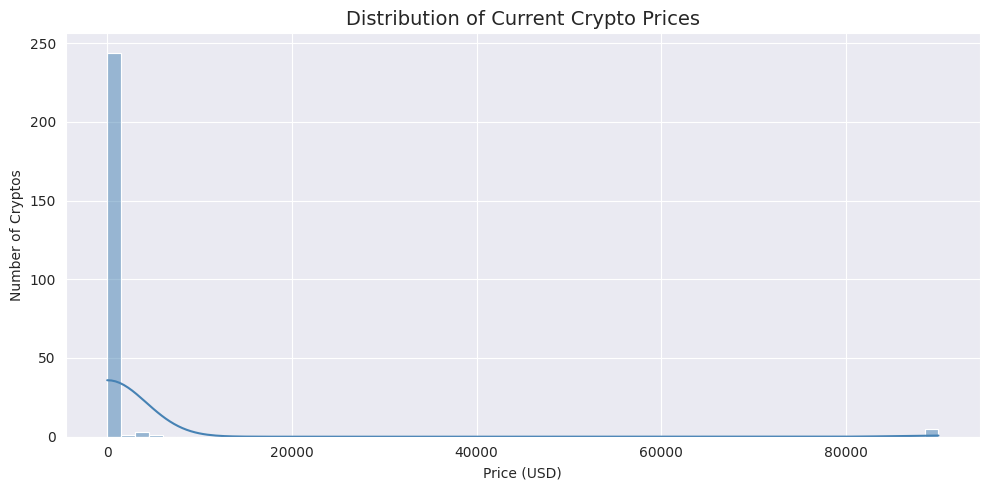

In [ ]:
# ═══════════════════════════════════════════════
# I plotted the price distribution to understand
# how prices are spread across all 500 coins.
# The KDE curve on top shows the overall shape —
# I expected it to be heavily skewed since Bitcoin
# is priced at $90K+ while most coins are near $0.
# ═══════════════════════════════════════════════

plt.figure(figsize=(10, 5))

sns.histplot(df['current_price'], bins=60, color='steelblue', kde=True)

plt.title("Distribution of Current Crypto Prices", fontsize=14)
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cryptos")

plt.tight_layout()
plt.show()

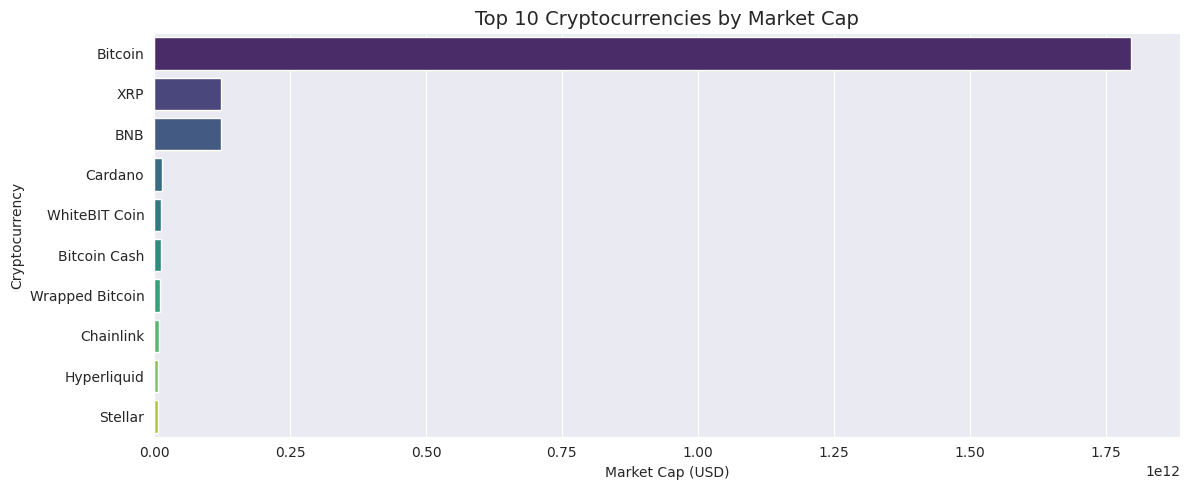

In [ ]:
# ═══════════════════════════════════════════════
# I sorted the dataset by market cap and picked
# the top 10 to see which coins dominate the market.
# This instantly showed Bitcoin's massive lead —
# its market cap was incomparably larger than
# every other coin in the top 10 combined.
# ═══════════════════════════════════════════════

top10 = df.sort_values(by='market_cap', ascending=False).head(10)

plt.figure(figsize=(12, 5))

sns.barplot(x='market_cap', y='name', data=top10, palette='viridis')

plt.title("Top 10 Cryptocurrencies by Market Cap", fontsize=14)
plt.xlabel("Market Cap (USD)")
plt.ylabel("Cryptocurrency")

plt.tight_layout()
plt.show()

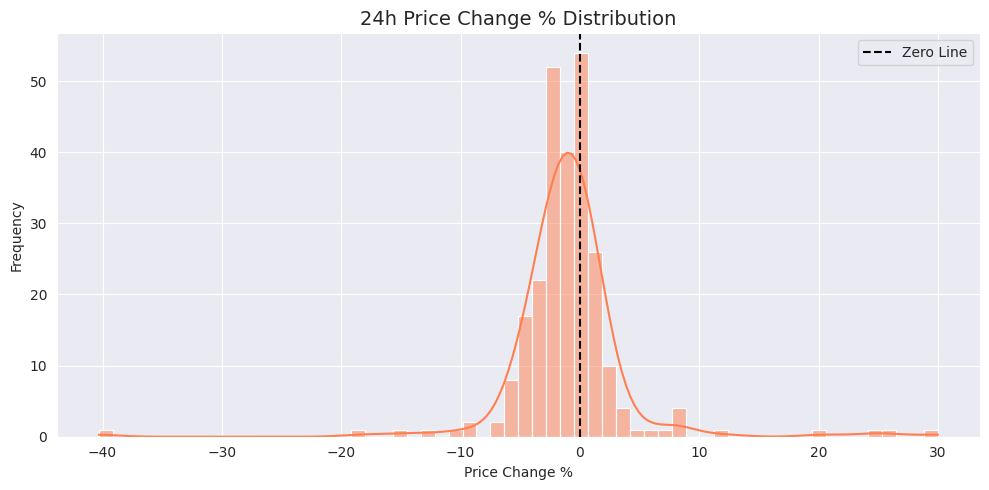

In [ ]:
# ═══════════════════════════════════════════════
# To understand short-term volatility, I looked at
# the distribution of 24-hour price change %. The
# dashed line at 0% works as a reference point:
# values on the right are gains and on the left
# are losses. This helps quickly judge whether the
# overall market snapshot is mostly bullish or bearish.
# ═══════════════════════════════════════════════

plt.figure(figsize=(10, 5))

sns.histplot(
    df['price_change_percentage_24h'].dropna(),
    bins=60,
    color='coral',
    kde=True
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Zero Line')

plt.title("24h Price Change % Distribution", fontsize=14)
plt.xlabel("Price Change %")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

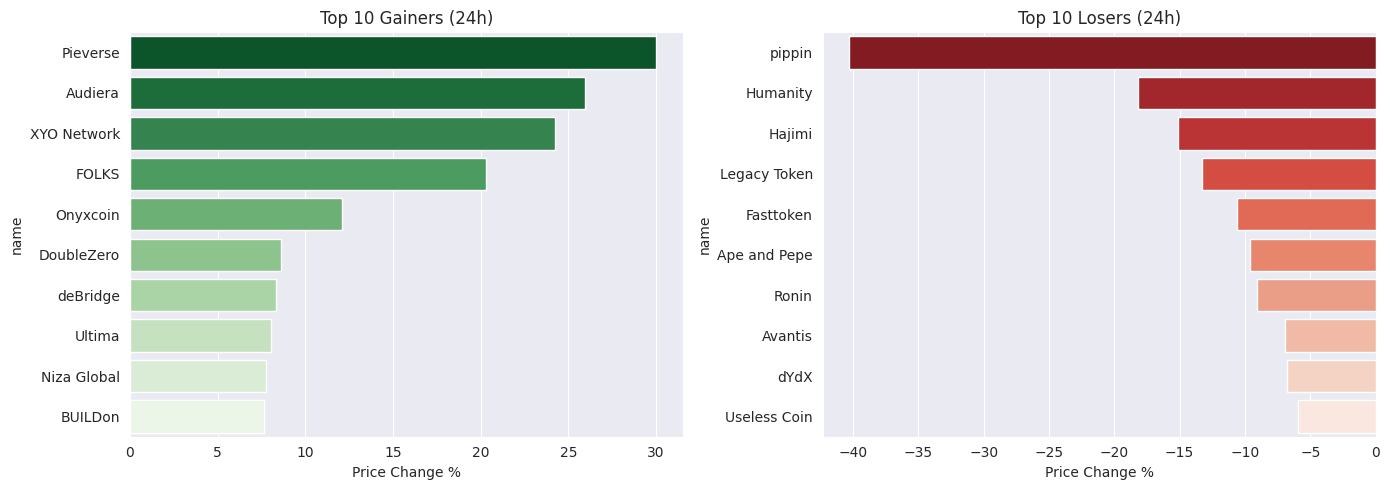

In [ ]:
# ═══════════════════════════════════════════════
# I wanted to see which coins moved the most in
# both directions within 24 hours. So I extracted
# top 10 gainers and top 10 losers separately and
# plotted them side by side — green for gains and
# red for losses. This makes it very easy to spot
# the most volatile coins in the current snapshot.
# ═══════════════════════════════════════════════

top_gainers = df.nlargest(10, 'price_change_percentage_24h')[['name', 'price_change_percentage_24h']]
top_losers = df.nsmallest(10, 'price_change_percentage_24h')[['name', 'price_change_percentage_24h']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x='price_change_percentage_24h',
    y='name',
    data=top_gainers,
    palette='Greens_r',
    ax=axes[0]
)
axes[0].set_title("Top 10 Gainers (24h)")
axes[0].set_xlabel("Price Change %")

sns.barplot(
    x='price_change_percentage_24h',
    y='name',
    data=top_losers,
    palette='Reds_r',
    ax=axes[1]
)
axes[1].set_title("Top 10 Losers (24h)")
axes[1].set_xlabel("Price Change %")

plt.tight_layout()
plt.show()

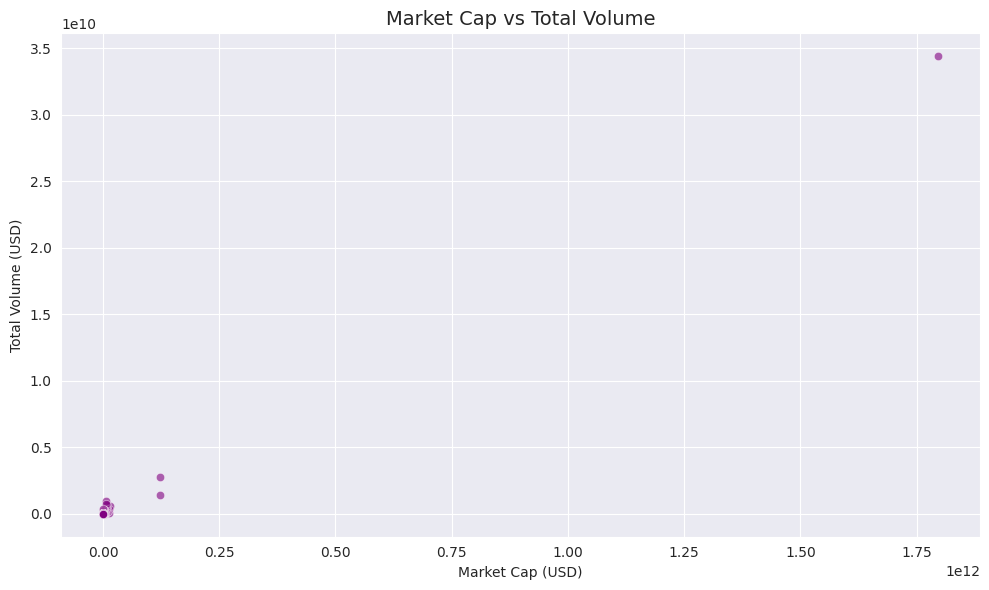

In [ ]:
# ═══════════════════════════════════════════════
# I plotted market cap against trading volume to
# see if larger coins trade more. Generally they do
# but some small cap coins showed surprisingly high
# volume — which points to speculative activity.
# Bitcoin appeared as a clear outlier sitting far
# away from the rest of the coins on both axes.
# ═══════════════════════════════════════════════

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='market_cap',
    y='total_volume',
    data=df,
    alpha=0.6,
    color='purple'
)

plt.title("Market Cap vs Total Volume", fontsize=14)
plt.xlabel("Market Cap (USD)")
plt.ylabel("Total Volume (USD)")

plt.tight_layout()
plt.show()

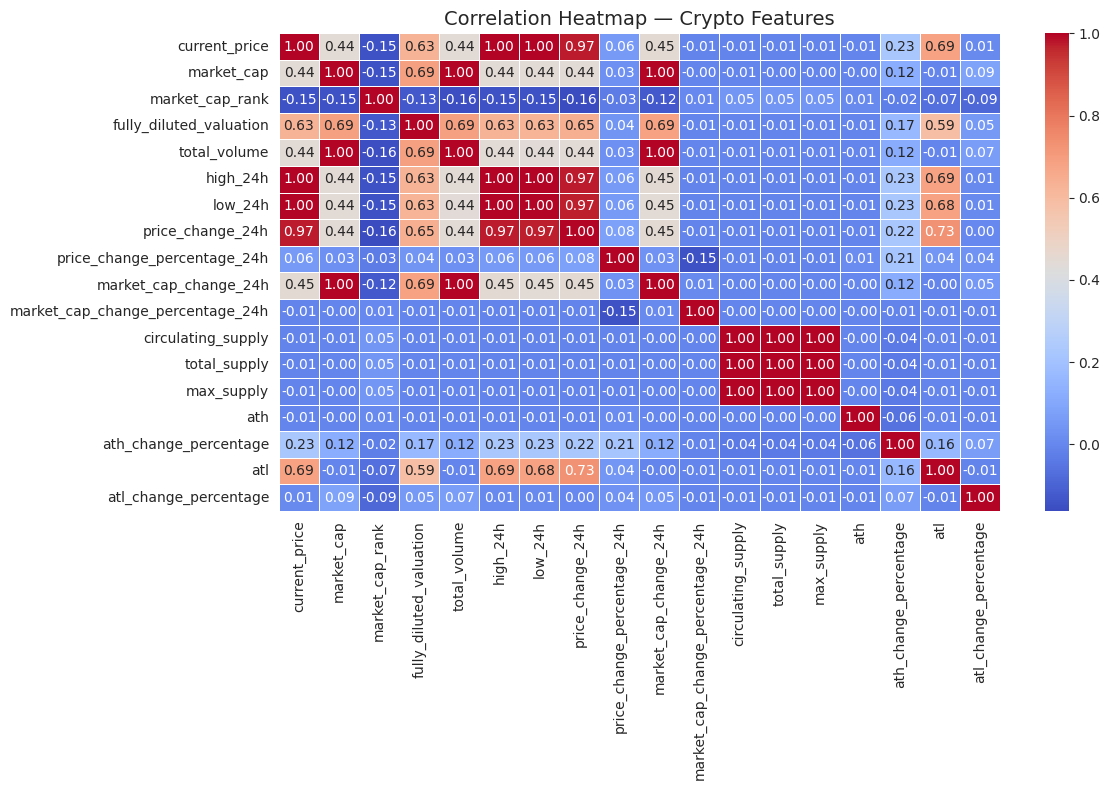

In [ ]:
# ═══════════════════════════════════════════════
# I used a correlation heatmap to understand how
# numeric features relate to each other. I selected
# only numeric columns first because passing text
# columns like name or symbol would throw an error.
# Red means strong positive correlation, blue means
# negative — this helped me pick the right features
# for the ML model and avoid redundant ones.
# ═══════════════════════════════════════════════

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap — Crypto Features", fontsize=14)
plt.tight_layout()
plt.show()

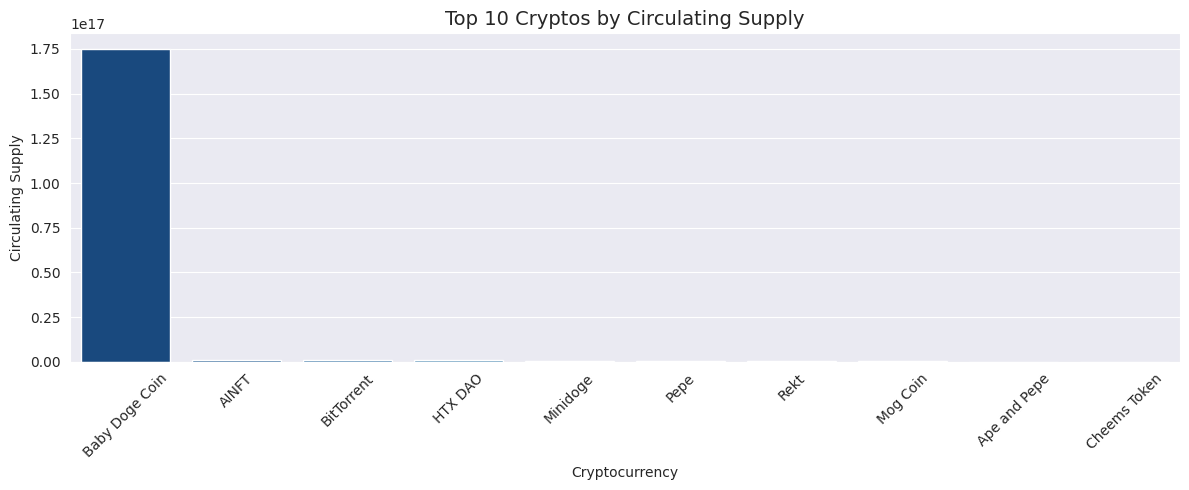

In [ ]:
# ═══════════════════════════════════════════════
# Circulating supply directly impacts a coin's
# unit price — more coins in circulation usually
# means a lower individual price. I plotted the
# top 10 by supply to see which coins have the
# most units in the market and how that reflects
# in their relatively low per-coin pricing.
# ═══════════════════════════════════════════════

top_supply = df.nlargest(10, 'circulating_supply')[['name', 'circulating_supply']]

plt.figure(figsize=(12, 5))

sns.barplot(x='name', y='circulating_supply', data=top_supply, palette='Blues_r')

plt.xticks(rotation=45)
plt.title("Top 10 Cryptos by Circulating Supply", fontsize=14)
plt.xlabel("Cryptocurrency")
plt.ylabel("Circulating Supply")

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════
# Here I created a few meaningful features from the
# raw columns so the analysis and ML model become
# more informative. First I created the target label
# (UP/DOWN) using 24h price change. Then I added
# three financial indicators: how far the coin is
# from its ATH, how much it recovered from ATL, and
# a liquidity ratio (volume relative to market cap).
# These engineered features capture market position
# and trading activity better than raw values alone.
# ═══════════════════════════════════════════════

df['Target'] = (df['price_change_percentage_24h'] > 0).astype(int)
df['ath_drop_pct'] = ((df['ath'] - df['current_price']) / df['ath']) * 100
df['atl_rise_pct'] = ((df['current_price'] - df['atl']) / df['atl']) * 100
df['volume_to_mcap'] = df['total_volume'] / df['market_cap']

print("✅ Feature Engineering Complete!")
print(df[['name', 'Target', 'ath_drop_pct', 'atl_rise_pct', 'volume_to_mcap']].head(10))

✅ Feature Engineering Complete!
              name  Target  ath_drop_pct  atl_rise_pct  volume_to_mcap
0          Bitcoin       1     28.589784  1.326739e+05        0.019143
1              XRP       1     44.109589  7.584343e+04        0.022757
2              BNB       1     34.879087  2.240486e+06        0.011409
3          Cardano       1     86.506699  2.065628e+03        0.040438
4    WhiteBIT Coin       1      4.085511  1.879412e+03        0.007257
5     Bitcoin Cash       1     84.221912  6.764591e+02        0.028346
6  Wrapped Bitcoin       1     28.651177  2.762253e+03        0.018347
7        Chainlink       0     74.193548  9.077841e+03        0.066837
8      Hyperliquid       0     50.556492  6.695538e+02        0.043268
9          Stellar       0     73.010966  4.953161e+04        0.014431


In [ ]:
# ═══════════════════════════════════════════════
# Before training the model, I separated the dataset
# into input features (X) and the target label (y).
# I only selected numeric columns because ML models
# can't directly learn from text fields like name or
# symbol. Finally, I checked the shape of X and the
# UP/DOWN count in y to understand the data size and
# whether the classes are balanced or not.
# ═══════════════════════════════════════════════

features = [
    'current_price',
    'market_cap',
    'total_volume',
    'circulating_supply',
    'ath',
    'atl',
    'ath_drop_pct',
    'atl_rise_pct',
    'volume_to_mcap'
]

X = df[features]
y = df['Target']

print(f"✅ Features Shape: {X.shape}")
print(f"✅ Target Distribution:\n{y.value_counts()}")

✅ Features Shape: (254, 9)
✅ Target Distribution:
Target
0    168
1     86
Name: count, dtype: int64


In [ ]:
# ═══════════════════════════════════════════════
# To evaluate the model fairly, I split the data
# into training and testing sets. The model learns
# patterns only from the training set and then I
# test its performance on unseen data (test set).
# I kept 80% for training and 20% for testing, and
# used a fixed random_state so results stay the same
# every time the notebook is run.
# ═══════════════════════════════════════════════

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"✅ Training Set: {X_train.shape}")
print(f"✅ Testing Set:  {X_test.shape}")

✅ Training Set: (203, 9)
✅ Testing Set:  (51, 9)


In [ ]:
# ═══════════════════════════════════════════════
# Since features like market_cap and total_volume
# are extremely large compared to ratios like
# volume_to_mcap, I scaled the data so every feature
# comes on a similar range. I fitted the scaler only
# on the training set to avoid data leakage, and then
# applied the same transformation to the test set.
# ═══════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature Scaling Done!")

✅ Feature Scaling Done!


In [ ]:
# ═══════════════════════════════════════════════
# Instead of training just one algorithm, I trained
# multiple classification models to compare results.
# Logistic Regression acts as a simple baseline,
# Decision Tree captures rule-based patterns, and
# Random Forest (an ensemble of many trees) usually
# performs better on complex, non-linear datasets.
# I trained each model on the same scaled training
# data and generated predictions on the same test set
# for a fair comparison.
# ═══════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("✅ All Models Trained!")

✅ All Models Trained!


In [ ]:
# ═══════════════════════════════════════════════
# After training all three models, I compared them
# using accuracy on the same test set. This gave me
# a quick and consistent way to choose the best
# performing model for the final dashboard and report.
# ═══════════════════════════════════════════════

results = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Decision Tree':       accuracy_score(y_test, dt_pred),
    'Random Forest':       accuracy_score(y_test, rf_pred)
}

print("=== Model Accuracy Comparison ===")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f} ({acc*100:.2f}%)")

=== Model Accuracy Comparison ===
Logistic Regression: 0.8235 (82.35%)
Decision Tree: 0.6078 (60.78%)
Random Forest: 0.6863 (68.63%)


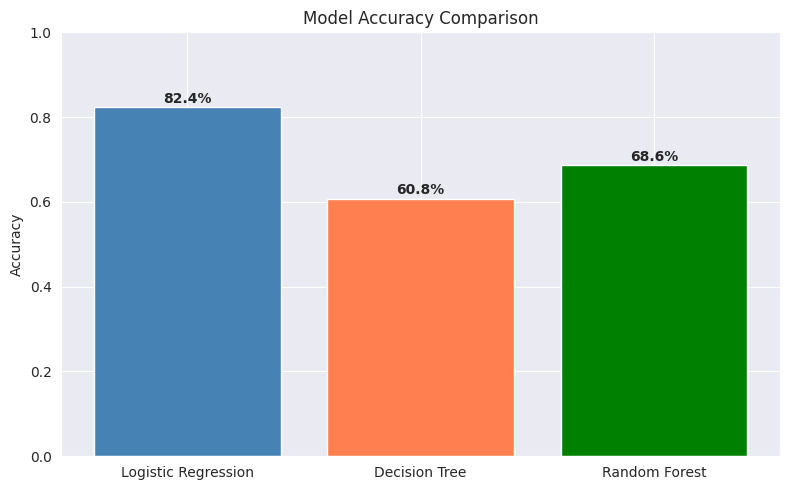

In [ ]:
# ═══════════════════════════════════════════════
# To make the model comparison easier to present,
# I plotted the accuracy scores in a simple bar chart.
# This gives a quick visual view of which algorithm
# performed best. I also added the accuracy values
# as labels on top of each bar for clarity.
# ═══════════════════════════════════════════════

plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'coral', 'green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════
# Accuracy alone doesn't tell the full story, so I
# used a classification report for the best model
# (Random Forest). It shows precision, recall and
# F1-score for both classes (UP and DOWN), which is
# important especially when the dataset is slightly
# imbalanced between the two classes.
# ═══════════════════════════════════════════════

print("=== Random Forest — Classification Report ===\n")
print(classification_report(y_test, rf_pred))

=== Random Forest — Classification Report ===

              precision    recall  f1-score   support

           0       0.72      0.92      0.80        36
           1       0.40      0.13      0.20        15

    accuracy                           0.69        51
   macro avg       0.56      0.53      0.50        51
weighted avg       0.62      0.69      0.63        51



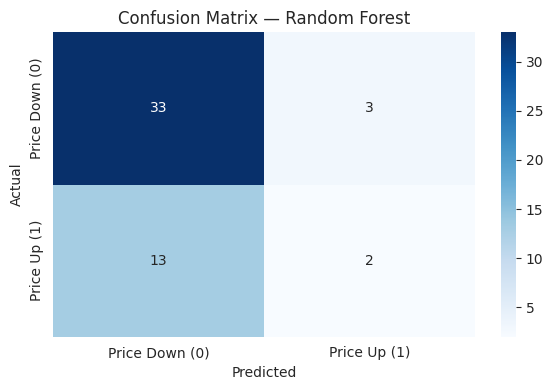

In [ ]:
# ═══════════════════════════════════════════════
# To visually check how the model is performing,
# I created a confusion matrix. It shows how many
# UP and DOWN predictions were correct and where the
# model made mistakes (false positives / false negatives).
# This is more informative than accuracy because it
# explains the type of errors the model is making.
# ═══════════════════════════════════════════════

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Price Down (0)', 'Price Up (1)'],
    yticklabels=['Price Down (0)', 'Price Up (1)']
)
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

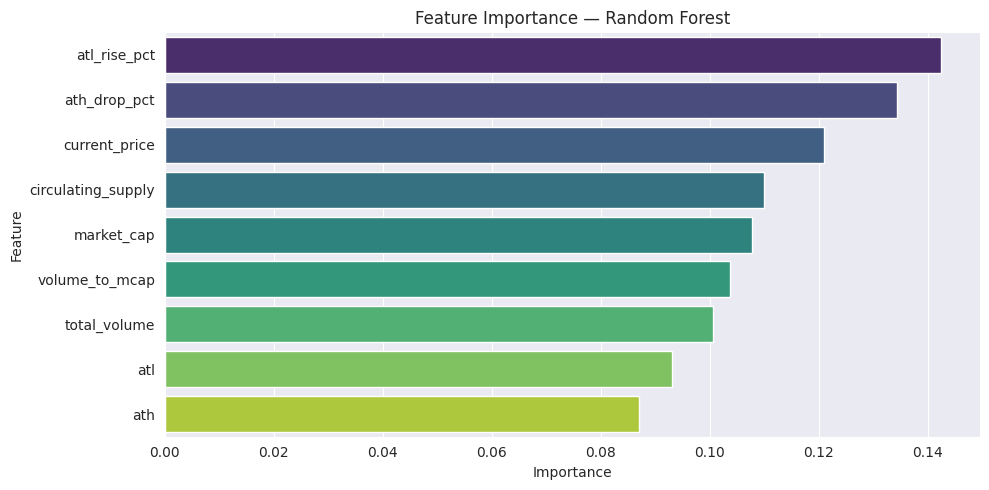

              Feature  Importance
7        atl_rise_pct    0.142446
6        ath_drop_pct    0.134399
0       current_price    0.120977
3  circulating_supply    0.110019
1          market_cap    0.107771
8      volume_to_mcap    0.103722
2        total_volume    0.100599
5                 atl    0.093048
4                 ath    0.087017
              Feature  Importance
7        atl_rise_pct    0.142446
6        ath_drop_pct    0.134399
0       current_price    0.120977
3  circulating_supply    0.110019
1          market_cap    0.107771
8      volume_to_mcap    0.103722
2        total_volume    0.100599
5                 atl    0.093048
4                 ath    0.087017


In [ ]:
# ═══════════════════════════════════════════════
# Random Forest allows us to see which features
# influenced the predictions the most. So I extracted
# feature importance scores and plotted them in
# descending order. This makes the model more
# interpretable and helps explain the results in the
# report — for example, whether liquidity ratio or
# market cap contributed more to UP/DOWN prediction.
# ═══════════════════════════════════════════════

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

print(importance)
print(importance)

In [ ]:
# ═══════════════════════════════════════════════
# After finalizing the model, I generated predictions
# for the full cleaned dataset and added them back
# as new columns (numeric + readable label). Then I
# exported the final dataset to a CSV file so it can
# be directly used in Power BI / Tableau for building
# the interactive dashboard.
# ═══════════════════════════════════════════════

df_export = df.copy()
df_export['Predicted_Movement'] = rf.predict(scaler.transform(df[features]))
df_export['Predicted_Label'] = df_export['Predicted_Movement'].map({1: 'UP', 0: 'DOWN'})

df_export.to_csv("crypto_analysis_final.csv", index=False)

from google.colab import files
files.download("crypto_analysis_final.csv")

print("✅ File exported and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File exported and downloaded!


In [ ]:
# ═══════════════════════════════════════════════
# At the end, I printed a short project summary so
# all key results are visible in one place. This is
# useful for reporting because it quickly shows how
# many coins were analyzed, how many features were
# used, the UP/DOWN distribution, the best model
# selected, and its final accuracy on the test set.
# ═══════════════════════════════════════════════

print("=" * 50)
print("📊 PROJECT SUMMARY")
print("=" * 50)
print(f"Total Cryptos Analyzed    : {len(df)}")
print(f"Features Used in Model    : {len(features)}")
print(f"Coins with Price UP (24h) : {df['Target'].sum()}")
print(f"Coins with Price DOWN     : {(df['Target'] == 0).sum()}")
print(f"Best Model                : Random Forest")
print(f"Best Accuracy             : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print("=" * 50)

📊 PROJECT SUMMARY
Total Cryptos Analyzed    : 254
Features Used in Model    : 9
Coins with Price UP (24h) : 86
Coins with Price DOWN     : 168
Best Model                : Random Forest
Best Accuracy             : 68.63%
